from google.colab import drive
drive.mount("/content/MyDrive")

##Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import hashlib
from tqdm.notebook import tqdm
import os
warnings.filterwarnings('ignore')
import psutil
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from transformers import RobertaTokenizer,AutoTokenizer,AutoConfig,BertForPreTraining,AutoModel,BertModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,TensorDataset
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from collections import defaultdict
from sklearn.model_selection import train_test_split
import random
from torch.optim import AdamW
import time

In [2]:
keep_frac = 0.02

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
def memory_check():
  return round(psutil.virtual_memory().used/1024**3,3)

os.chdir('/content/MyDrive/MyDrive/Colab Notebooks/securityBERT')

In [5]:
label_col = "Label"  # or the actual name of your attack type column
encoded_data_file_name = f'./saved_data/encoded_data_CICIDS2017_{keep_frac}samples'
tokenizer_file_name = f'./tokenizer_CICIDS2017_{keep_frac}samples'

##Load saved data

In [6]:
data = pd.read_pickle(f'{encoded_data_file_name}.pck')

In [7]:
le = LabelEncoder()
data['target'] = le.fit_transform(data[label_col])

In [8]:
data.sample(3)

,encoded_PPFLE,Label,target
613269,3d1d7e658155e860b3e58a6f7dca1d341c1022a3 eb4e6...,Bruteforce-SSH,3
612081,9c51125c62d3c5b6ae94f52223bc0a77fa008b8b 8cbc0...,Bruteforce-SSH,3
357158,efe3c4b761c455dc8031390eae9f2c87a98321a0 cb528...,DDoS-HOIC,7


In [9]:
data['encoded_PPFLE'][0]

'ffc159170fac1f54a2b693d30ee2f6c6c1e747e0 6e1ad5ebac4489fc5c3b6995e6496b6631a0a9ee ca403eef8cfa63b7076cbe664774ec35e36b6dfa 3ae729858be3ed966a204c679e6afa4b0852ff0b 5fd906459364dd8e8567e6ec956583c7231dfbae a25f85eacf0ec6fbe7e5afa39047539c0e59317b 3086708d7b1fef9b25dd5c83f0b7f7cd0ac1a8ca 09454b68d8627dfd13f22dcd02dd90a5aa41ab7c 8644b33819807fdb99fed5e9fb2fc8a23f1d2168 8294ded6336cb4ee652c58bc96d9bf188e8ab7d1 3c485ff5e1fbf84104a608d0926de6e07ab7e581 aad5326d4f2fd6f7919f0d326b881c579a7273f5 07f49c86900107c5a7cf78d5bcb2d67c6358ddce f92d337e1b50aac5f13ef8613de0715d1ad2fa79 a88fca179332287e6a9f40f141b0245951a6c75c d433d83b5c91aec48a520bf0ec4d2d808a386aeb b1fcc91b53d3d74db6e5bdf3004095746f60dfc0 de0e789c31d2df3ba4941e2363b2327678e50186 f548a676319a5165daff6e03d10954bf08f9d940 bf1e325b066fb36cc8bdbe81b4f3e4b22ce92a9b 368485a6709fafbda617c04fba1b264406e14f7b a3acb6e8839fbd50f9c761752c0650122343f792 59b1b2c36a38657686637be1a51af9cab3bd0417 37df8b5017856fde4ff11d551ffaa553cc16a63b 0b595d961323631

In [10]:
sorted(data['target'].unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32]

In [11]:
# data.to_pickle('./encoded_data.pickle')

In [12]:
memory_check()

14.707

##Data splitting

In [13]:
train_set = data.sample(frac=0.7,random_state=42).reset_index(drop=True)

remaining = data.drop(train_set.index).reset_index(drop=True)

test_set = remaining.sample(frac=0.5,random_state=42).reset_index(drop=True)

val_set = remaining.drop(test_set.index).reset_index(drop=True)

print(train_set.shape,val_set.shape,test_set.shape)

(625939, 3) (134129, 3) (134130, 3)


In [14]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [15]:
train_set, test_set = train_test_split(data, test_size=test_ratio,stratify=data.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)


In [16]:
train_set.shape,val_set.shape,test_set.shape

((625938, 3), (134130, 3), (134130, 3))

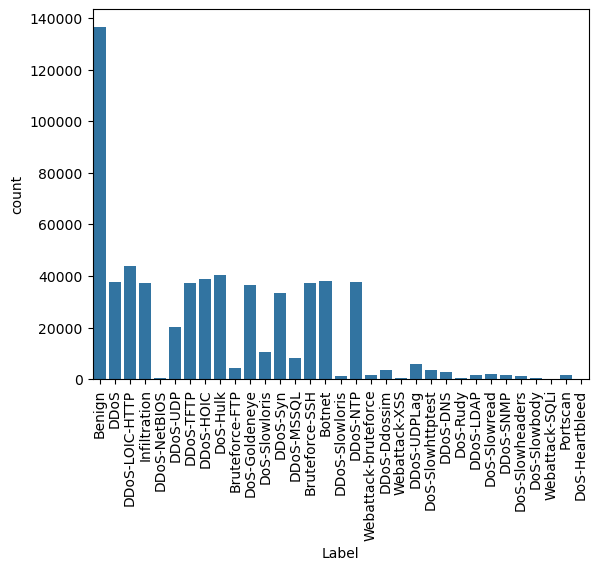

In [17]:
sns.countplot(train_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

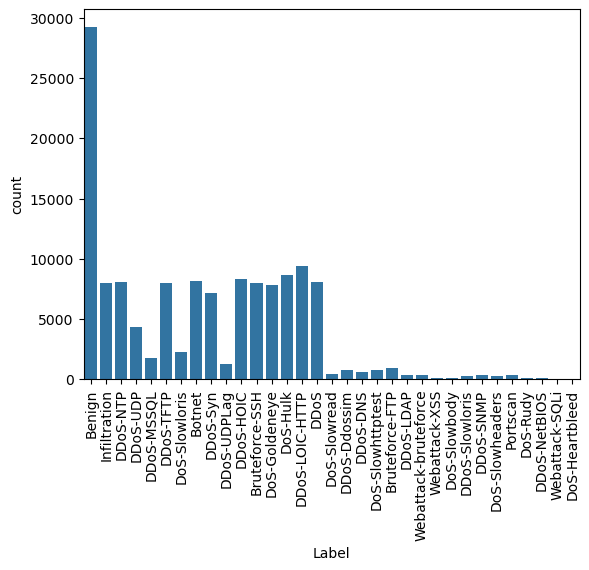

In [18]:
sns.countplot(val_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

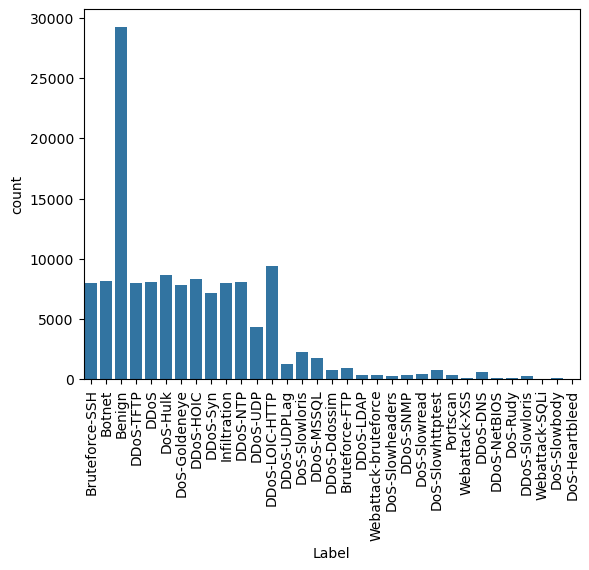

In [19]:
sns.countplot(test_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

In [20]:
TARGET_LIST = le.classes_
TARGET_LIST

array(['Benign', 'Botnet', 'Bruteforce-FTP', 'Bruteforce-SSH', 'DDoS',
       'DDoS-DNS', 'DDoS-Ddossim', 'DDoS-HOIC', 'DDoS-LDAP',
       'DDoS-LOIC-HTTP', 'DDoS-MSSQL', 'DDoS-NTP', 'DDoS-NetBIOS',
       'DDoS-SNMP', 'DDoS-Slowloris', 'DDoS-Syn', 'DDoS-TFTP', 'DDoS-UDP',
       'DDoS-UDPLag', 'DoS-Goldeneye', 'DoS-Heartbleed', 'DoS-Hulk',
       'DoS-Rudy', 'DoS-Slowbody', 'DoS-Slowheaders', 'DoS-Slowhttptest',
       'DoS-Slowloris', 'DoS-Slowread', 'Infiltration', 'Portscan',
       'Webattack-SQLi', 'Webattack-XSS', 'Webattack-bruteforce'],
      dtype=object)

In [21]:
data[data[label_col]=='Uploading'].head(5)

,encoded_PPFLE,Label,target


##BBPE algorithm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [23]:
SPECIAL_TOKENS = [
    '<pad>',
    '<s>',
    '</s>',
    '<mask>',
    '<unk>'
]
VOCAB_SIZE = 10000

In [24]:
tokenizer = RobertaTokenizer.from_pretrained(tokenizer_file_name)

In [25]:
len(tokenizer.get_vocab())

10000

##Dataset and DataLoader

In [26]:
class CustomDataset(Dataset):
  def __init__(self,df,tokenizer,max_len):
    self.df = df
    self.tokenizer = tokenizer
    self.max_len=max_len
    self.sequence = self.df['encoded_PPFLE'].tolist()
    self.targets = self.df['target'].tolist()

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    sequence = str(self.sequence[idx])
    target = self.targets[idx]
    encoding = self.tokenizer.encode_plus(
        sequence,
        add_special_tokens=True,
        max_length=self.max_len,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    return {
        'input_ids':encoding['input_ids'].flatten(),
        'attention_mask':encoding['attention_mask'].flatten(),
        'targets':torch.tensor(target,dtype=torch.long)
    }


In [27]:
MAX_LEN=512
BATCH_SIZE=32

In [28]:
train_dataset = CustomDataset(train_set,tokenizer=tokenizer,max_len=MAX_LEN)
val_dataset = CustomDataset(val_set,tokenizer=tokenizer,max_len=MAX_LEN)
test_dataset = CustomDataset(test_set,tokenizer=tokenizer,max_len=MAX_LEN)

In [29]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0

)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

#Fine tuning BERT

In [30]:
config = AutoConfig.from_pretrained("bert-base-uncased")
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.0.dev0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
config.hidden_size = 256
config.num_hidden_layers = 4
config.num_attention_heads = 16
config.intermediate_size = 512
config.vocab_size=VOCAB_SIZE

config.cls_token_id=tokenizer.convert_tokens_to_ids("<s>")
config.sep_token_id=tokenizer.convert_tokens_to_ids("</s>")
config.pad_token_id=tokenizer.convert_tokens_to_ids("<pad>")
config.mask_token_id=tokenizer.convert_tokens_to_ids("<mask>")
config.unk_token_id=tokenizer.convert_tokens_to_ids("<unk>")

In [32]:
finetunedBERT = AutoModel.from_config(config)

In [33]:
finetunedBERT

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(10000, 256, padding_idx=0)
    (position_embeddings): Embedding(512, 256)
    (token_type_embeddings): Embedding(2, 256)
    (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-3): 4 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=256, out_features=256, bias=True)
            (key): Linear(in_features=256, out_features=256, bias=True)
            (value): Linear(in_features=256, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=256, out_features=256, bias=True)
            (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)


###Model paramerters

In [34]:
sum(p.numel() for p in finetunedBERT.parameters())

4866304

##Model definition

In [35]:
class SecurityBERT(nn.Module):
  def __init__(self,finetunedBERT,n_classes):
    super(SecurityBERT,self).__init__()
    self.bert = finetunedBERT
    self.dropout = nn.Dropout(p=0.1)
    self.out = nn.Linear(self.bert.config.hidden_size,n_classes)

  def forward(self,input_ids,attention_mask):
    pooled_output = self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).pooler_output

    output = self.dropout(pooled_output)

    return self.out(output)


###Subsection of training


In [ ]:
def load_chkpt(model,version):
  return model.load_state_dict(torch.load(f"./saved_model/securityBert3_mod_CICIDS2017_{version}.0.pt",map_location=torch.device('cpu')))

##Training and Evaluation

In [37]:
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    #print("input_ids shape:", input_ids.shape)
    #print("input_ids max:", input_ids.max().item())
    #print("input_ids min:", input_ids.min().item())
    #print("BERT vocab size:", model.bert.config.vocab_size)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)
    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)

    optimizer.step()
    scheduler.step()

    optimizer.zero_grad()

  return correct_predictions/n_examples,np.mean(losses)




In [38]:
def evaluation_model(model,data_loader,loss_fn,device,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)

    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

  return correct_predictions/n_examples,np.mean(losses)

In [39]:
securityBert = SecurityBERT(finetunedBERT=finetunedBERT,n_classes=len(TARGET_LIST)).to(device)
EPOCHS=3
optimizer = torch.optim.AdamW(securityBert.parameters(),lr=1e-5)
total_steps = len(train_loader)*EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps= 0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss().to(device)

In [40]:
def clean_float_str(x):
    return ('{:.10f}'.format(x)).rstrip('0').rstrip('.')  # Keeps precision up to 10 digits, then trims

In [ ]:
model_directory = "saved_model/"
model_version = f"securityBERT3_mod_CICIDS2017_{keep_frac}samples"
figure_version = f"SecurityBERT3 CIC-IDS-2017 (Modified) {clean_float_str(keep_frac * 100)}% Samples"
figure_file_name = f'securityBert3-Cicids2017-mod-{keep_frac}samples'
num_epochs=3

In [ ]:
%%time
history = defaultdict(list)
best_accuracy=0
start_time = time.time()

for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch {epoch+1}/{EPOCHS}")
  train_acc,train_loss = train_model(securityBert,train_loader,loss_fn,optimizer,device,scheduler,len(train_set))
  val_acc,val_loss = evaluation_model(securityBert,val_loader,loss_fn,device,len(val_set))
  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  print(f"Train Loss {train_loss} | Validation Loss {val_loss} |Training Accuracy {train_acc} |Validation Accuracy {val_acc}")

  if val_acc>best_accuracy:
    save_dir = f'./{model_directory}'
    # Create the directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    torch.save(securityBert.state_dict(),f"./{model_directory}{model_version}_{epoch+1}.0.pt")
    best_accuracy = val_acc

history['training_time'].append(time.time() - start_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3
Train Loss 0.8941744943722388 | Validation Loss 0.5140060044697109 |Training Accuracy 0.7333953380584717 |Validation Accuracy 0.8221277594566345
Epoch 2/3
Train Loss 0.4773036467629317 | Validation Loss 0.458274292181964 |Training Accuracy 0.8322086334228516 |Validation Accuracy 0.8351449966430664
Epoch 3/3
Train Loss 0.4462171286273302 | Validation Loss 0.44604531448789453 |Training Accuracy 0.8384743928909302 |Validation Accuracy 0.8382390141487122
CPU times: total: 4h 30min 57s
Wall time: 4h 35min 50s


48m 33.2s

In [43]:
torch.save(history,f"./{model_directory}history_{model_version}.pt")
test_indices = test_set.index.to_numpy()
np.save(f"./{model_directory}test_indices_{model_version}.npy", test_indices)

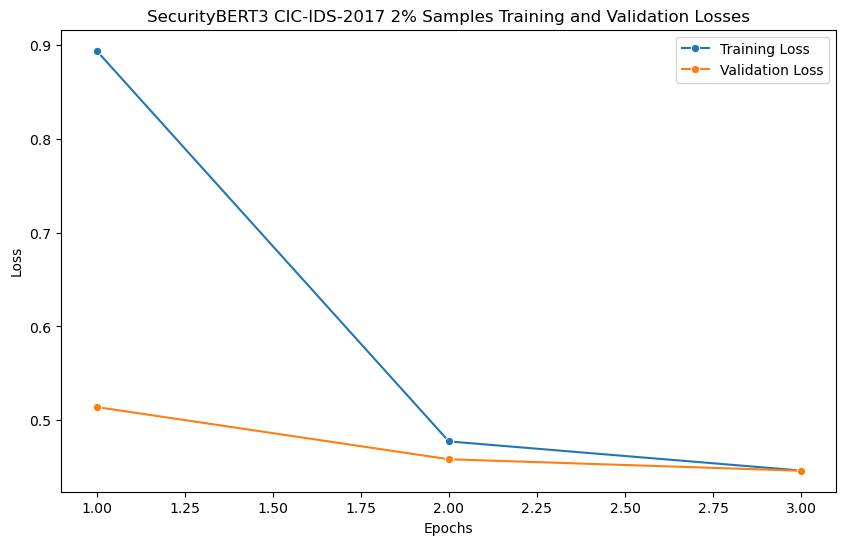

In [44]:

epochs = range(1, EPOCHS+1)
train_losses = history['train_loss']
val_losses = history['val_loss']

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_losses, label='Training Loss',marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss',marker="o")

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-losses.png',dpi=780)
# Affichage du graphique
plt.show()


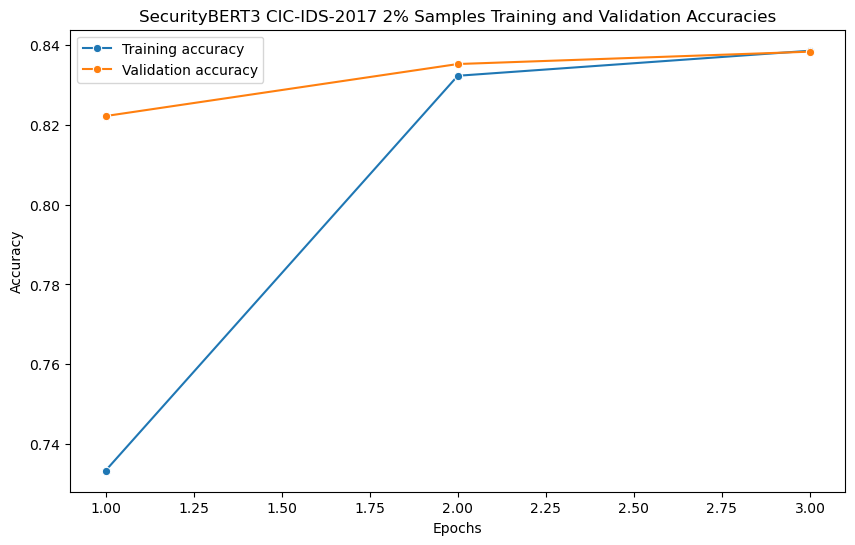

In [45]:
epochs = range(1, EPOCHS+1)
train_accuracies = [tens.item() for tens in history['train_acc']]
val_accuracies = [tens.item() for tens in history['val_acc']]

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o')
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o')

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-accuracies.png',dpi=780)
# Affichage du graphique
plt.show()


In [ ]:
def get_predictions(model, test_loader):
        model = model.eval()

        predictions, predictions_probs, real_values = [], [], []
        total_time = 0.0
        total_samples = 0

        with torch.no_grad():
            for data in tqdm(test_loader, desc="Predictions"):
                input_ids = data['input_ids'].to(device)
                attention_mask = data['attention_mask'].to(device)
                targets = data['targets'].to(device)

                start_time = time.perf_counter()

                outputs = model(input_ids, attention_mask)

                end_time = time.perf_counter()

                # Track time and sample count
                batch_size = input_ids.size(0)
                total_samples += batch_size
                total_time += (end_time - start_time)

                _, preds = torch.max(outputs, dim=1)
                probs = F.softmax(outputs, dim=1)

                predictions.extend(preds)
                predictions_probs.extend(probs)
                real_values.extend(targets)

        # Stack outputs
        predictions = torch.stack(predictions).cpu()
        predictions_probs = torch.stack(predictions_probs).cpu()
        real_values = torch.stack(real_values).cpu()

        # Calculate average inference time per sample (in milliseconds)
        avg_inference_time_ms = (total_time / total_samples) * 1000

        print(f"Average per-sample inference time: {avg_inference_time_ms:.4f} ms")

        return predictions, predictions_probs, real_values, avg_inference_time_ms

In [ ]:
y_pred,y_proba,real_values,inference_time = get_predictions(securityBert,test_loader)

Predictions:   0%|          | 0/4192 [00:00<?, ?it/s]

In [ ]:
torch.save(y_pred,f"./{model_directory}y_pred_{model_version}.pt")
torch.save(y_proba,f"./{model_directory}y_proba_{model_version}.pt")
torch.save(real_values,f"./{model_directory}real_values_{model_version}.pt")
torch.save(inference_time,f"./{model_directory}inference_time_{model_version}.pt")

In [50]:
from sklearn.metrics import confusion_matrix,classification_report

In [51]:
target_names = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
       'XSS']

In [52]:
s = set()

In [53]:
for elt in y_pred:
  s.add(elt.item())

In [54]:
actual_considered_classes = [TARGET_LIST[i] for i in s]
actual_considered_classes

['Benign',
 'Botnet',
 'Bruteforce-FTP',
 'Bruteforce-SSH',
 'DDoS',
 'DDoS-DNS',
 'DDoS-Ddossim',
 'DDoS-HOIC',
 'DDoS-LDAP',
 'DDoS-LOIC-HTTP',
 'DDoS-MSSQL',
 'DDoS-NTP',
 'DDoS-Slowloris',
 'DDoS-Syn',
 'DDoS-TFTP',
 'DDoS-UDP',
 'DDoS-UDPLag',
 'DoS-Goldeneye',
 'DoS-Hulk',
 'DoS-Slowheaders',
 'DoS-Slowhttptest',
 'DoS-Slowloris',
 'DoS-Slowread',
 'Infiltration',
 'Portscan',
 'Webattack-bruteforce']

In [55]:
data[label_col].value_counts()

Label
Benign                  195001
DDoS-LOIC-HTTP           62784
DoS-Hulk                 57652
DDoS-HOIC                55254
Botnet                   54196
DDoS                     53838
DDoS-NTP                 53704
DDoS-TFTP                53254
Bruteforce-SSH           53222
Infiltration             53174
DoS-Goldeneye            52324
DDoS-Syn                 47757
DDoS-UDP                 28863
DoS-Slowloris            15243
DDoS-MSSQL               11784
DDoS-UDPLag               8452
Bruteforce-FTP            5984
DoS-Slowhttptest          5271
DDoS-Ddossim              5115
DDoS-DNS                  3668
DoS-Slowread              2786
Portscan                  2255
DDoS-LDAP                 2092
Webattack-bruteforce      2020
DDoS-SNMP                 2017
DDoS-Slowloris            1858
DoS-Slowheaders           1649
Webattack-XSS              876
DoS-Rudy                   699
DDoS-NetBIOS               675
DoS-Slowbody               621
Webattack-SQLi              99
Do

In [56]:
def show_confusion_matrix(confusion_matrix, annot):

    plt.figure(figsize=(20, 12))
    sns.heatmap(confusion_matrix, annot=annot, cmap='Blues', fmt='')
    plt.xticks(rotation=90)
    plt.title(f"{figure_version} {num_epochs} Epochs Confusion Matrix")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig(f'./{figure_file_name}-{num_epochs}ep-confusion-matrix.png',bbox_inches="tight",dpi=780)
    plt.show()

In [57]:
from sklearn.metrics import confusion_matrix,classification_report

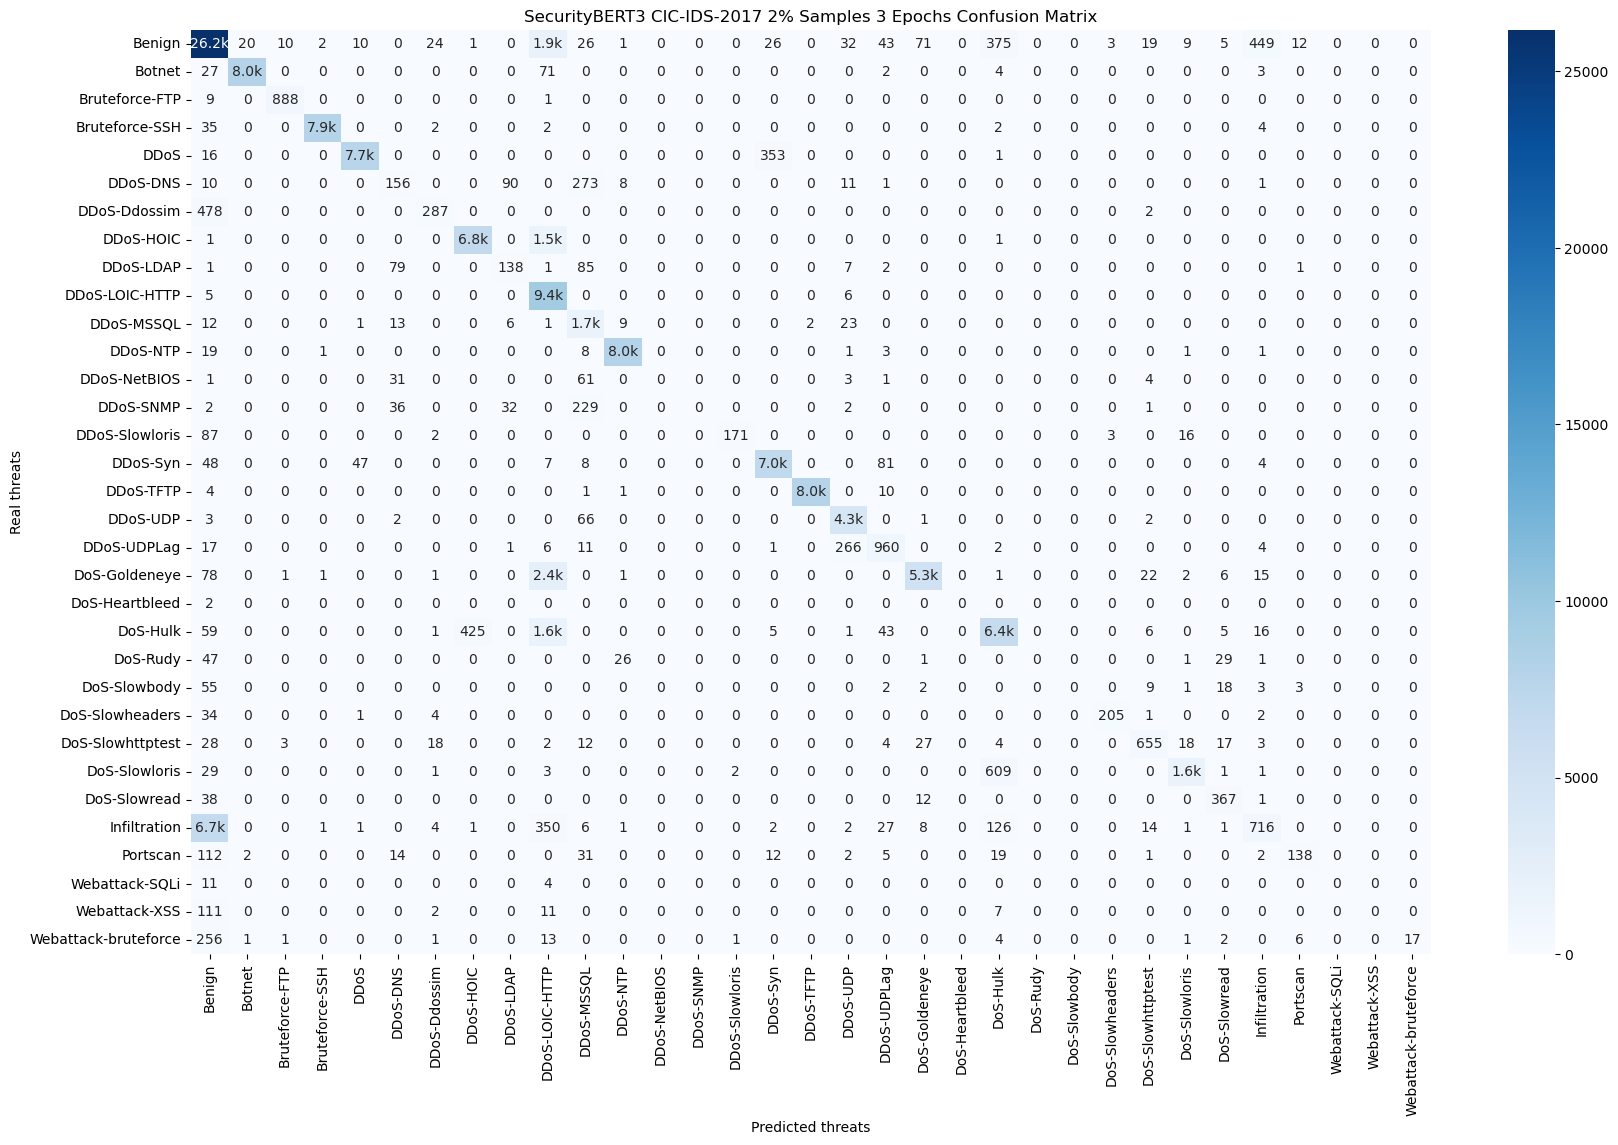

In [58]:
cm = confusion_matrix(real_values,y_pred)

def format_k(x):
    return f"{x/1000:.1f}k" if x >= 1000 else str(x)

# Create formatted annotations
annot = np.array([[format_k(val) for val in row] for row in cm])
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm, annot)

In [59]:
print(classification_report(real_values,y_pred,target_names=TARGET_LIST))

                      precision    recall  f1-score   support

              Benign       0.76      0.89      0.82     29250
              Botnet       1.00      0.99      0.99      8129
      Bruteforce-FTP       0.98      0.99      0.99       898
      Bruteforce-SSH       1.00      0.99      1.00      7983
                DDoS       0.99      0.95      0.97      8076
            DDoS-DNS       0.47      0.28      0.35       550
        DDoS-Ddossim       0.83      0.37      0.52       767
           DDoS-HOIC       0.94      0.82      0.88      8288
           DDoS-LDAP       0.52      0.44      0.48       314
      DDoS-LOIC-HTTP       0.54      1.00      0.70      9418
          DDoS-MSSQL       0.68      0.96      0.79      1768
            DDoS-NTP       0.99      1.00      0.99      8056
        DDoS-NetBIOS       0.00      0.00      0.00       101
           DDoS-SNMP       0.00      0.00      0.00       302
      DDoS-Slowloris       0.98      0.61      0.75       279
       

In [60]:
s = set()
for elt in y_pred:
    s.add(elt.item())
actual_considered_classes = [le.classes_[i] for i in s]
print(actual_considered_classes)

counts = test_set['target'].value_counts().sort_index()
class_names = le.inverse_transform(counts.index)
class_counts = pd.Series(counts.values, index=class_names)
class_counts = class_counts.sort_values(ascending=False)  # or .sort_index()
print(class_counts)

['Benign', 'Botnet', 'Bruteforce-FTP', 'Bruteforce-SSH', 'DDoS', 'DDoS-DNS', 'DDoS-Ddossim', 'DDoS-HOIC', 'DDoS-LDAP', 'DDoS-LOIC-HTTP', 'DDoS-MSSQL', 'DDoS-NTP', 'DDoS-Slowloris', 'DDoS-Syn', 'DDoS-TFTP', 'DDoS-UDP', 'DDoS-UDPLag', 'DoS-Goldeneye', 'DoS-Hulk', 'DoS-Slowheaders', 'DoS-Slowhttptest', 'DoS-Slowloris', 'DoS-Slowread', 'Infiltration', 'Portscan', 'Webattack-bruteforce']
Benign                  29250
DDoS-LOIC-HTTP           9418
DoS-Hulk                 8648
DDoS-HOIC                8288
Botnet                   8129
DDoS                     8076
DDoS-NTP                 8056
DDoS-TFTP                7988
Bruteforce-SSH           7983
Infiltration             7976
DoS-Goldeneye            7849
DDoS-Syn                 7164
DDoS-UDP                 4329
DoS-Slowloris            2286
DDoS-MSSQL               1768
DDoS-UDPLag              1268
Bruteforce-FTP            898
DoS-Slowhttptest          791
DDoS-Ddossim              767
DDoS-DNS                  550
DoS-Slowread  

In [61]:
y_true = real_values.cpu().numpy()
y_score = y_pred.cpu().numpy()

In [62]:
import matplotlib.pyplot as plt

def plot_test_metrics_table(test_metrics, figure_version, num_epochs, figure_file_name):
    """
    Plots and saves a table of test metrics as a figure.

    Parameters:
    - test_metrics: defaultdict or dict with scalar values
    - figure_version: str (e.g., 'v1.0')
    - num_epochs: int
    - figure_file_name: str (e.g., 'tab-transformer')
    """

    # Define a mapping from metric keys to display names
    metric_name_map = {
        "micro_acc": "Overall Accuracy",
        "micro_rec": "Overall Recall",
        "micro_prec": "Overall Precision",
        "micro_f1": "Overall F1 Score",
        "micro_roc_auc": "Overall ROC AUC",
        "macro_acc": "Class-Averaged Accuracy",
        "macro_rec": "Class-Averaged Recall",
        "macro_prec": "Class-Averaged Precision",
        "macro_f1": "Class-Averaged F1 Score",
        "macro_roc_auc": "Class-Averaged ROC AUC",
        # Add more mappings as needed
    }

    # Convert metrics to a list of [metric_name, value] rows
    data = []
    for key, value in test_metrics.items():
        label = metric_name_map.get(key, key)  # Use key as fallback if not in map
        data.append([label, f"{value:.4f}"])

    fig, ax = plt.subplots(figsize=(8, len(data) * 0.4 + 1))
    ax.axis('off')

    table = ax.table(
        cellText=data,
        colLabels=["Metric", "Score"],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 1.5)

    plt.title(f"{figure_version} {num_epochs} Epochs Test Scores", fontsize=14, pad=20)

    output_path = f"./{figure_file_name}-{num_epochs}ep-test-scores.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


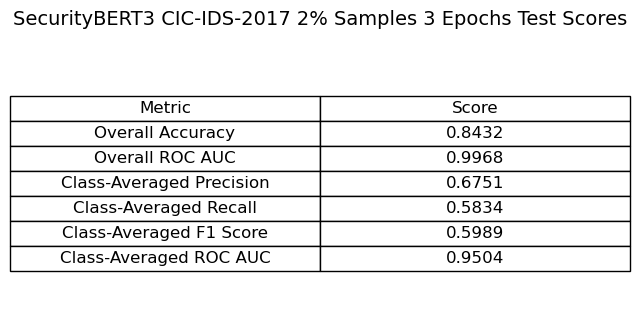

In [63]:
from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import torch
from sklearn.metrics import balanced_accuracy_score

# Assume these are already defined:
# y_true: true class labels (1D array-like)
# y_pred: predicted class labels (1D array-like)
# y_proba: predicted probabilities (2D array-like: [n_samples, n_classes])

n_classes = len(np.unique(y_true))
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

test_metrics = defaultdict(float)  # ⬅️ Each key holds a single float value

# Micro metrics
test_metrics["micro_acc"] = accuracy_score(y_true, y_pred)
try:
    test_metrics["micro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="micro", multi_class="ovr"
    )
except ValueError:
    test_metrics["micro_roc_auc"] = float("nan")

test_metrics["macro_prec"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_rec"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro")

# ROC AUC Scores
try:
    test_metrics["macro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="macro", multi_class="ovr"
    )
except ValueError:
    test_metrics["macro_roc_auc"] = float("nan")

# Save metrics
torch.save(dict(test_metrics), f"./{model_directory}test_metrics_{model_version}.pt")

# Plot
plot_test_metrics_table(test_metrics, figure_version=figure_version, num_epochs=num_epochs, figure_file_name=figure_file_name)